<a href="https://colab.research.google.com/github/YevheniiaMalchenko/ML/blob/main/%D0%9B%D0%913_%D0%9C%D0%B0%D0%BB%D1%8C%D1%87%D0%B5%D0%BD%D0%BA%D0%BE_3_10_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 3. Машинне навчання
## Регресія: прогнозування вартості нерухомості

**Мета роботи:** виконати первинний аналіз даних, побудувати кілька моделей регресії, оцінити їхню якість та виконати підбір гіперпараметрів для моделі Random Forest.

### Датасет
Можна використати один із двох способів завантаження даних:

1. Завантажити файл з Google Drive:
https://drive.google.com/file/d/1u_-3X05st6uvrgQB1qNLyE8a7QjTJjvd/view?usp=sharing

2. Завантажити датасет з Kaggle:
https://www.kaggle.com/datasets/prokshitha/home-value-insights

> Посилання та вміст датасету на зовнішніх платформах можуть змінюватися.

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [1]:
# Ваш код:
# Імпортуйте pandas, numpy, matplotlib.pyplot, seaborn та інші потрібні бібліотеки.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## 2. Завантаження даних
Оберіть **один** зі способів завантаження датасету.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [3]:
# Ваш код:
# Завантажте файл і збережіть дані у DataFrame `df`.

from google.colab import files
uploaded = files.upload()

Saving house_price_regression_dataset.csv to house_price_regression_dataset.csv


In [4]:
df = pd.read_csv('house_price_regression_dataset.csv')
display(df)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


### Варіант 2. Завантаження датасету з Kaggle
Завантажте датасет безпосередньо з Kaggle та прочитайте CSV-файл у DataFrame `df`.

In [8]:
# Ваш код:
# Завантажте датасет з Kaggle та створіть DataFrame `df`.

import kagglehub
import os
path = kagglehub.dataset_download("prokshitha/home-value-insights")
print("Шлях:", path)
df = pd.read_csv(os.path.join(path, "house_price_regression_dataset.csv"))
df.head()

Using Colab cache for faster access to the 'home-value-insights' dataset.
Шлях: /kaggle/input/home-value-insights


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


## 3. Опис ознак датасету

- **Square_Footage** — загальна житлова площа будинку.
- **Num_Bedrooms** — кількість спалень.
- **Num_Bathrooms** — кількість ванних кімнат.
- **Year_Built** — рік побудови будинку.
- **Lot_Size** — розмір земельної ділянки.
- **Garage_Size** — розмір гаража або кількість паркомісць.
- **Neighborhood_Quality** — оцінка якості району.
- **House_Price** — ціна будинку, цільова змінна.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [9]:
# Ваш код:
# Виведіть кілька перших рядків та загальну інформацію про DataFrame.

df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [11]:
# Ваш код:
# Порахуйте кількість дублікатів.
df.duplicated().sum()

np.int64(0)

### Завдання 3. Перевірка пропущених значень
Визначте кількість пропущених значень у кожному стовпці.

In [12]:
# Ваш код:
# Виведіть кількість пропусків для кожної ознаки.

df.isnull().sum()



,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


### Завдання 4. Описова статистика
Виведіть основні статистичні характеристики числових ознак.

In [ ]:
# Ваш код:
# Отримайте описову статистику датасету.
df.describe()


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## 5. Аналіз окремих ознак

### Завдання 5. Ознака `Neighborhood_Quality`
Виведіть частоти значень ознаки `Neighborhood_Quality`.

In [ ]:
# Ваш код:
# Порахуйте кількість спостережень для кожного значення `Neighborhood_Quality`.

df['Neighborhood_Quality'].value_counts()

,count
Neighborhood_Quality,
10,123
5,109
2,105
7,102
6,101
4,99
8,97
1,91
9,88


### Завдання 6. Візуалізація `Neighborhood_Quality`
Побудуйте діаграму розподілу значень цієї ознаки.

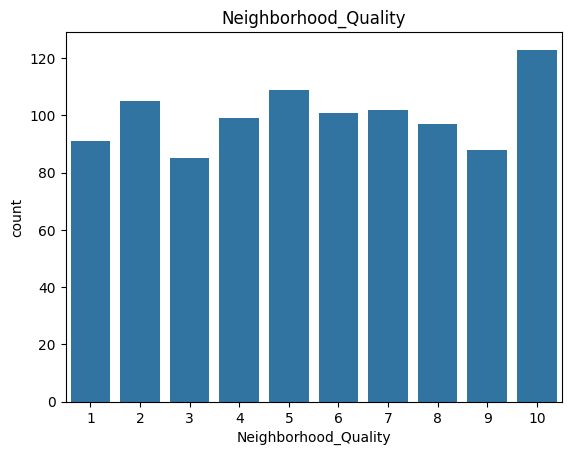

In [ ]:
# Ваш код:
# Побудуйте countplot або іншу відповідну діаграму.

sns.countplot(x='Neighborhood_Quality', data=df)
plt.title('Neighborhood_Quality')
plt.show()



### Завдання 7. Ознака `Num_Bathrooms`
Виведіть частоти значень кількості ванних кімнат.

In [ ]:
# Ваш код:
# Порахуйте кількість спостережень для кожного значення `Num_Bathrooms`.

df['Num_Bathrooms'].value_counts()


,count
Num_Bathrooms,
1,350
2,327
3,323


### Завдання 8. Візуалізація `Num_Bathrooms`
Побудуйте діаграму розподілу кількості ванних кімнат.

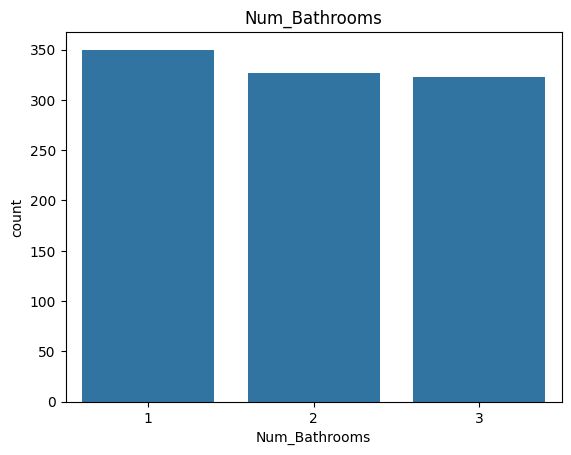

In [ ]:
# Ваш код:
# Побудуйте відповідну діаграму.

sns.countplot(x='Num_Bathrooms', data=df)
plt.title('Num_Bathrooms')
plt.show()




### Додаткове завдання
За потреби побудуйте попарні графіки числових ознак і коротко проаналізуйте можливі залежності.

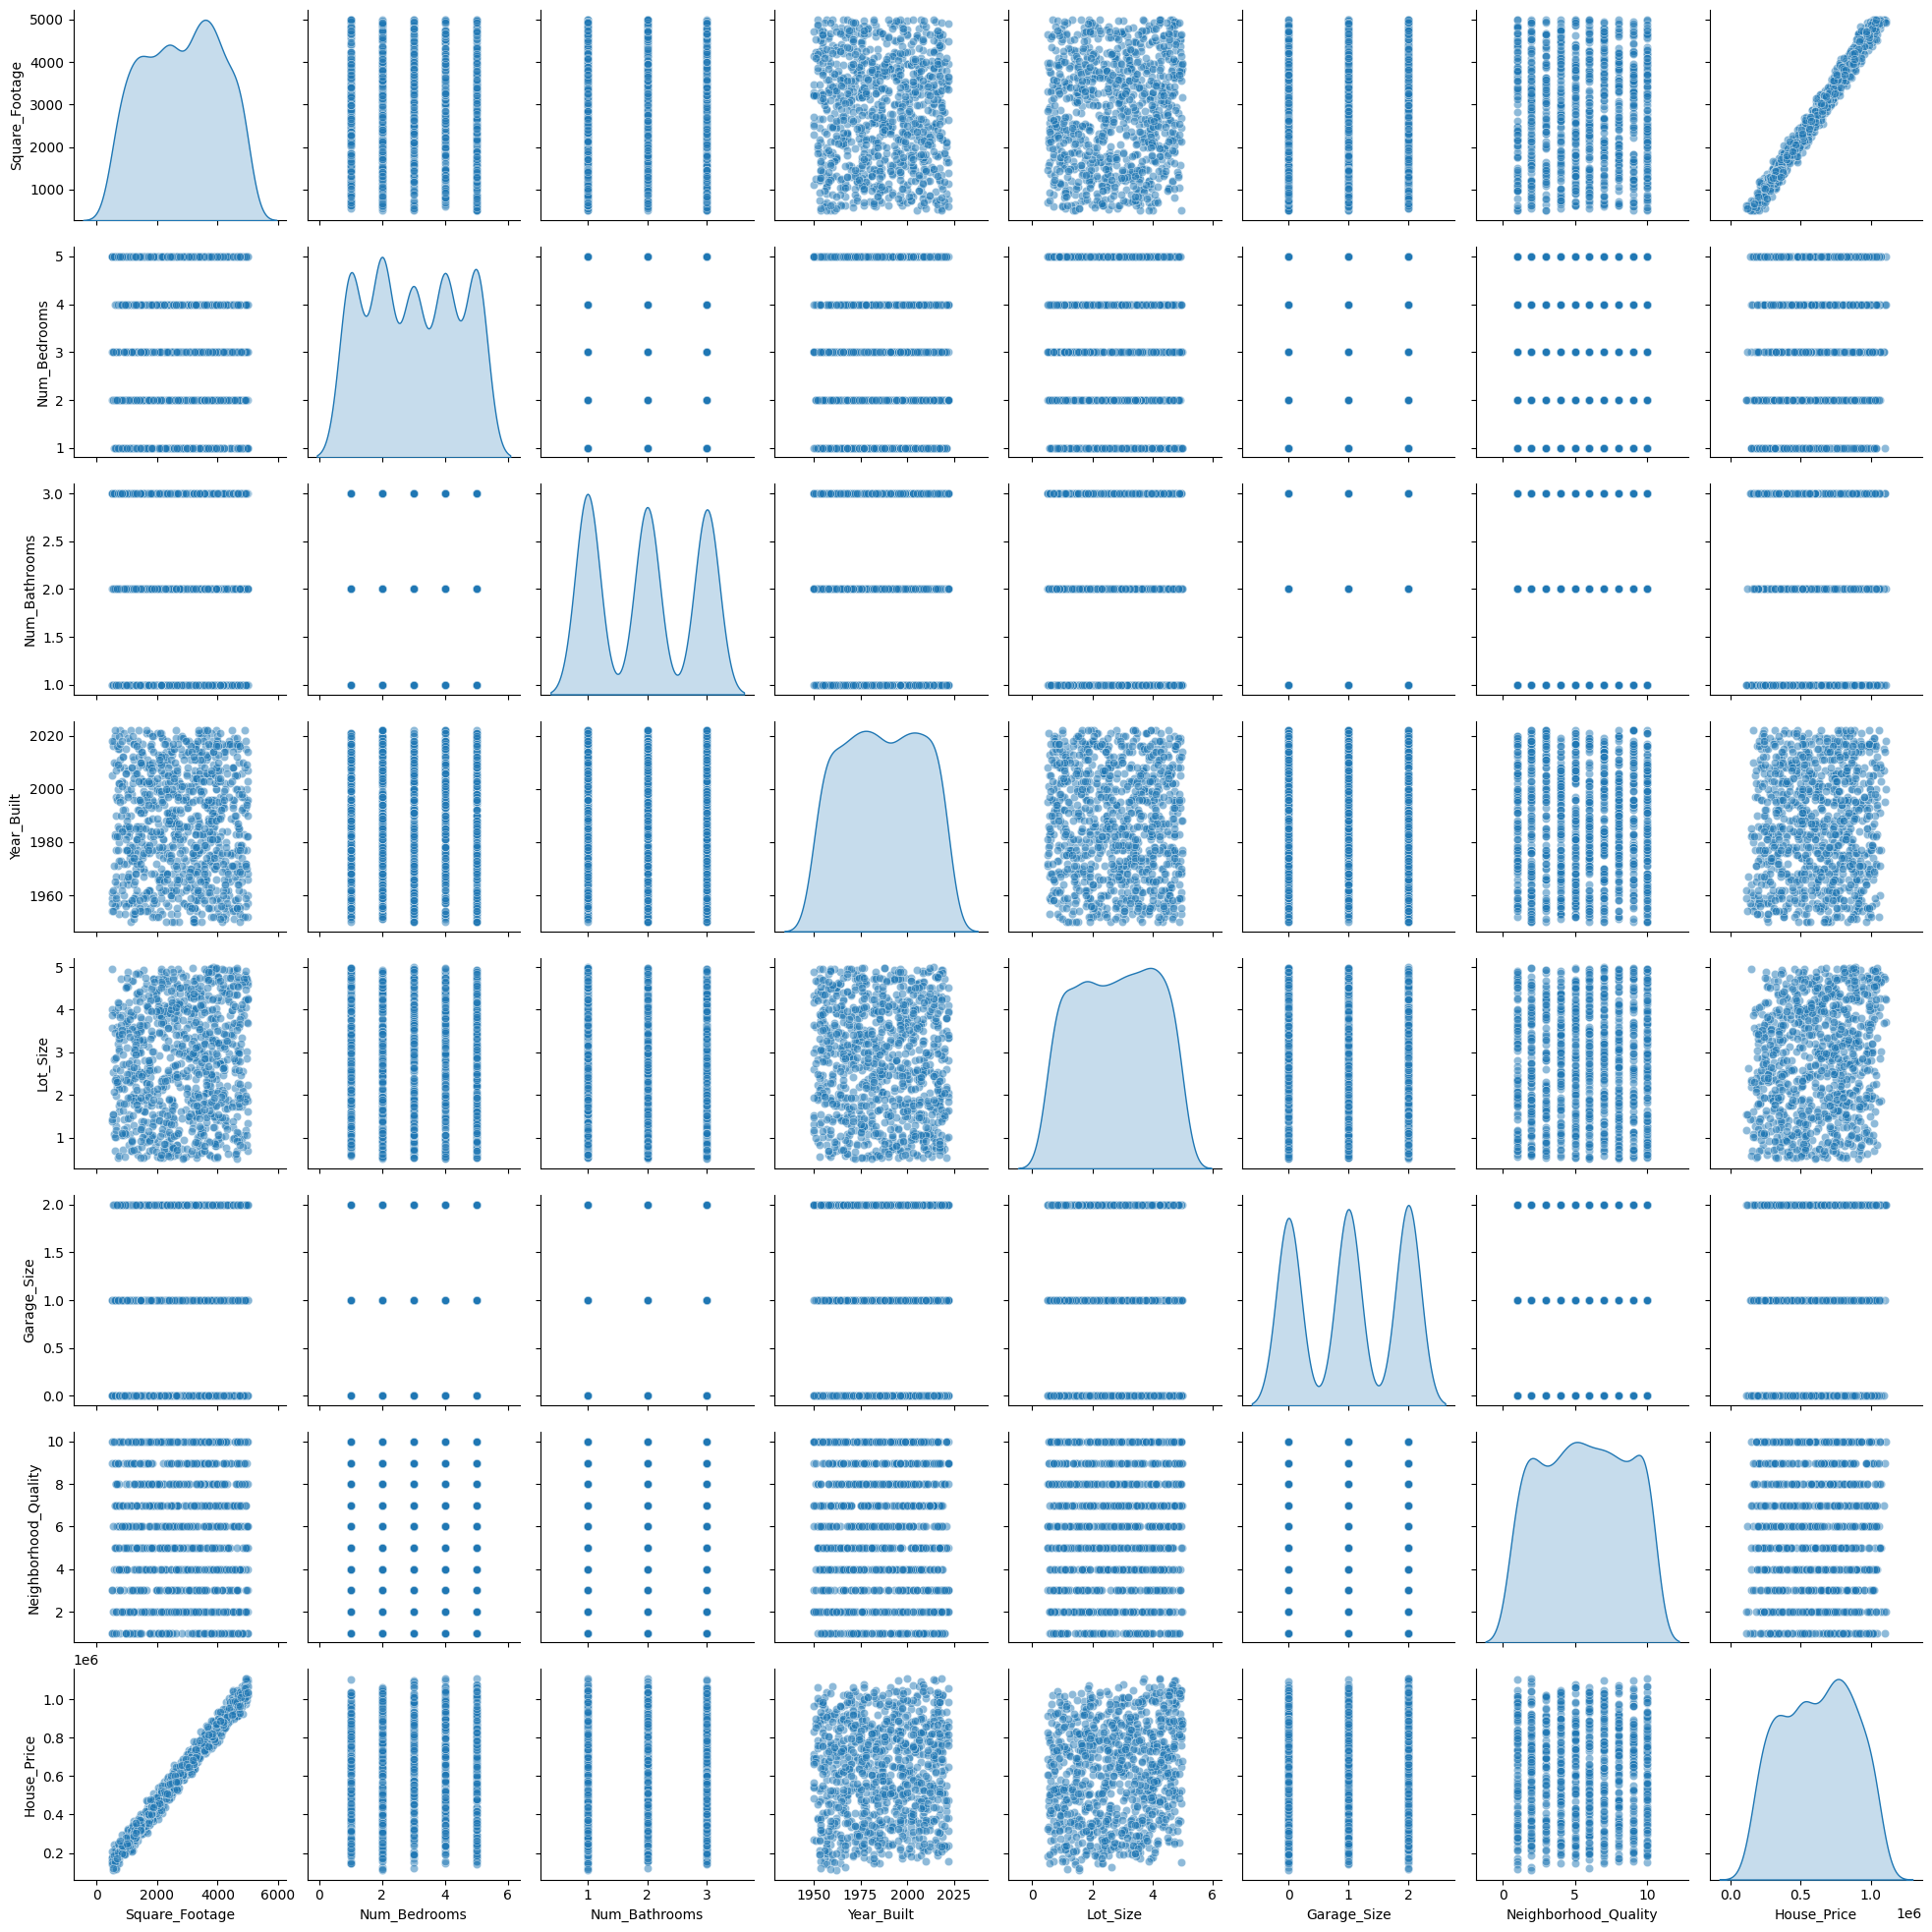

In [16]:
# Ваш код:
# Побудуйте pairplot або іншу попарну візуалізацію.
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

## 6. Кореляційний аналіз

### Завдання 9. Матриця кореляції
Побудуйте кореляційну матрицю для числових ознак та відобразіть її у вигляді теплової карти.

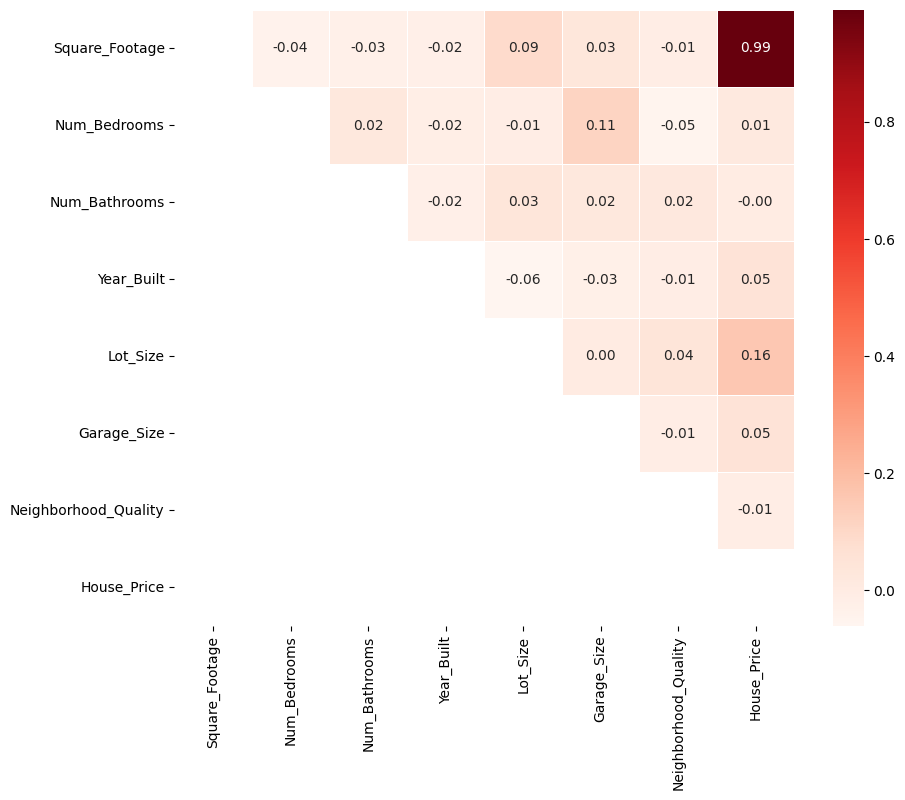

In [ ]:
# Ваш код:
# Обчисліть кореляційну матрицю та побудуйте heatmap.
corr = df.select_dtypes(include=[np.number]).corr()
mask = np.tril(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='Reds', cbar=True, linewidths=0.5)
plt.show()


### Завдання 10. Кореляція з цільовою змінною
Виведіть кореляцію кожної ознаки з `House_Price`, відсортувавши значення за спаданням.

In [17]:
# Ваш код:
# Виведіть кореляції ознак із `House_Price`.
df.select_dtypes(include=[np.number]).corr()['House_Price'].sort_values(ascending=False)

,House_Price
House_Price,1.000000
Square_Footage,0.991261
Lot_Size,0.160412
Garage_Size,0.052133
Year_Built,0.051967
Num_Bedrooms,0.014633
Num_Bathrooms,-0.001862
Neighborhood_Quality,-0.007770


## 7. Побудова моделей регресії

### Завдання 11. Імпорт інструментів Scikit-learn
Імпортуйте засоби для:
- поділу вибірки;
- масштабування ознак;
- побудови Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting;
- створення Pipeline;
- обчислення R², MAE та MSE.

In [18]:
# Ваш код:
# Імпортуйте необхідні класи та функції зі scikit-learn.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline

### Завдання 12. Формування `X` і `y`
Відокремте ознаки від цільової змінної `House_Price`.

In [19]:
# Ваш код:
# Створіть `X` та `y`.

X = df.drop(columns=['House_Price'])
y = df['House_Price']

### Завдання 13. Поділ даних
Поділіть дані на навчальну і тестову вибірки у співвідношенні 80/20. Для відтворюваності використайте `random_state=42`.

In [20]:
# Ваш код:
# Створіть `X_train`, `X_test`, `y_train`, `y_test`.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Завдання 14. Створення моделей
Створіть п’ять моделей:
1. Linear Regression;
2. Ridge;
3. Lasso;
4. Random Forest Regressor;
5. Gradient Boosting Regressor.

Для лінійних моделей використайте `Pipeline` зі `StandardScaler`. Для деревоподібних моделей масштабування не потрібне.

In [21]:
# Ваш код:
# Створіть словник або іншу структуру з п’ятьма моделями.
models = {
    "LinearRegression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    "Ridge": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.1, max_iter=10000))
    ]),
    "Random Forest Regressor": RandomForestRegressor(
        random_state=42
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        random_state=42
    )
}


### Завдання 15. Навчання та оцінювання моделей
Для кожної моделі:
- виконайте навчання на тренувальній вибірці;
- отримайте прогноз для тестової вибірки;
- обчисліть `R²`, `MAE`, `MSE`;
- збережіть результати для подальшого порівняння.

In [22]:
# Ваш код:
# Навчіть усі моделі, отримайте прогнози та метрики на тестовій вибірці.
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "R2": r2,
        "MAE": mae,
        "MSE": mse,
        "MAPE": mape
    }
    print(
        f"[{name}] R2: {r2:.3f} | MAE: {mae:.3f} | "
        f"MSE: {mse:.3f} | MAPE: {mape:.3f}"
    )




[LinearRegression] R2: 0.998 | MAE: 8174.584 | MSE: 101434798.506 | MAPE: 0.017
[Ridge] R2: 0.998 | MAE: 8241.587 | MSE: 102480990.009 | MAPE: 0.017
[Lasso] R2: 0.998 | MAE: 8174.607 | MSE: 101435077.051 | MAPE: 0.017
[Random Forest Regressor] R2: 0.994 | MAE: 16114.290 | MSE: 394131747.446 | MAPE: 0.032
[Gradient Boosting Regressor] R2: 0.997 | MAE: 12305.218 | MSE: 224965597.845 | MAPE: 0.025


### Завдання 16. Графічне порівняння прогнозів
Для кожної моделі побудуйте графік **фактичні значення vs прогнозовані значення**. Додайте лінію ідеального прогнозу.

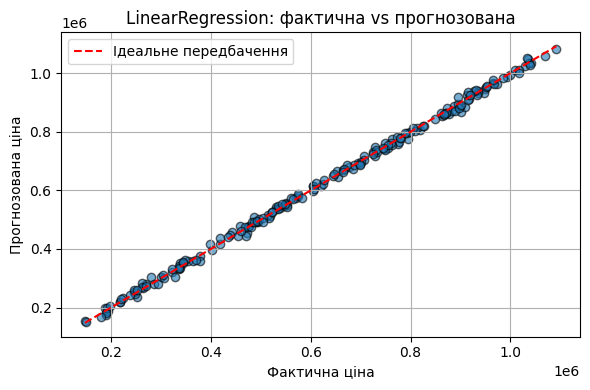

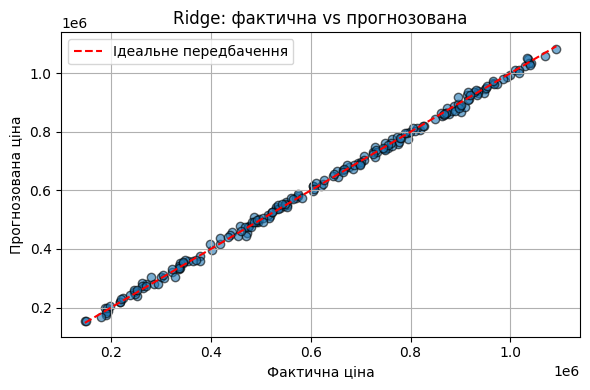

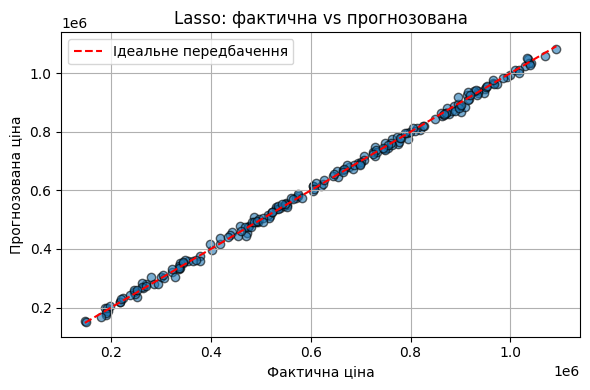

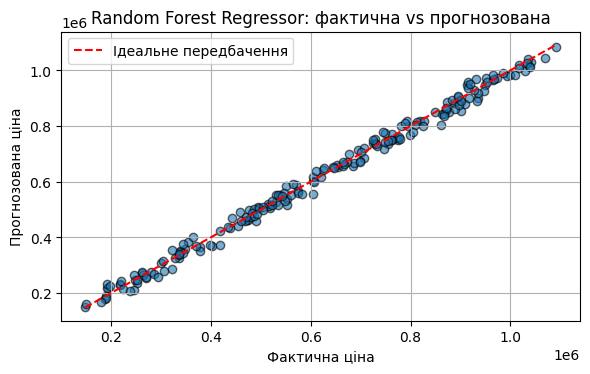

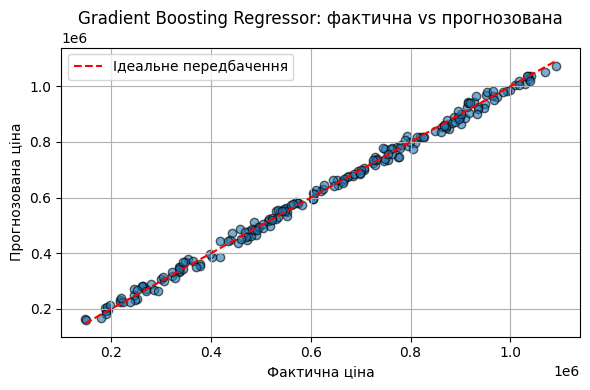

In [23]:
# Ваш код:
# Побудуйте окремий графік для кожної моделі.
for name, res in results.items():
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, res["y_pred"], alpha=0.6, edgecolors='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', label='Ідеальне передбачення')

    plt.xlabel("Фактична ціна")
    plt.ylabel("Прогнозована ціна")
    plt.title(f"{name}: фактична vs прогнозована")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()




## 8. Підбір гіперпараметрів Random Forest

### Завдання 17. GridSearchCV
Виконайте підбір оптимальних параметрів для `RandomForestRegressor` за допомогою `GridSearchCV`.

Дослідіть щонайменше такі параметри:
- `n_estimators`;
- `max_features`;
- `max_depth`;
- `min_samples_split`.

Використайте крос-валідацію та метрику `R²`.

In [24]:
# Ваш код:
# Створіть сітку параметрів, GridSearchCV і знайдіть найкращі параметри.
from sklearn.model_selection import GridSearchCV

param_rf = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

rf_reg_gs = RandomForestRegressor(random_state=42)

rf_search = GridSearchCV(
    estimator=rf_reg_gs,
    param_grid=param_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

best_rf_params = rf_search.best_params_

print("Найкращі параметри:")
print(best_rf_params)




Найкращі параметри:
{'max_depth': None, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 200}


### Завдання 18. Оптимізована модель Random Forest
Створіть нову модель з найкращими параметрами, навчіть її та обчисліть `R²`, `MAE`, `MSE` на тестовій вибірці.

In [26]:
# Ваш код:
# Навчіть оптимізований Random Forest та обчисліть метрики.
best_rf_model = RandomForestRegressor(**best_rf_params, random_state=42)
best_rf_model.fit(X_train, y_train)

y_pred_best_rf = best_rf_model.predict(X_test)

best_r2 = r2_score(y_test, y_pred_best_rf)
best_mae = mean_absolute_error(y_test, y_pred_best_rf)
best_mse = mean_squared_error(y_test, y_pred_best_rf)
best_mape = mean_absolute_percentage_error(y_test, y_pred_best_rf)
print(f"[Optimized Random Forest] R2: {best_r2:.3f} | MAE: {best_mae:.3f} | MSE: {best_mse:.3f} | MAPE: {best_mape:.3f}")

[Optimized Random Forest] R2: 0.994 | MAE: 16035.168 | MSE: 387229091.921 | MAPE: 0.032


### Завдання 19. Порівняння Random Forest до і після оптимізації
Порівняйте значення `R²`, `MAE` і `MSE` для базової та оптимізованої моделей.

In [30]:
# Ваш код:
# Виведіть результати двох моделей у зручному для порівняння вигляді.
base_rf = results["Random Forest Regressor"]
comparison_df = pd.DataFrame({
    "Модель": ["Базовий Random Forest", "Оптимізований Random Forest"],
    "R²": [base_rf["R2"], best_r2],
    "MAE": [base_rf["MAE"], best_mae],
    "MSE": [base_rf["MSE"], best_mse]
})
display(comparison_df)

,Модель,R²,MAE,MSE
0,Базовий Random Forest,0.993886,16114.289644,3.941317e+08
1,Оптимізований Random Forest,0.993993,16035.168080,3.872291e+08


### Завдання 20. Аналіз оптимізації
Зробіть короткий висновок:
- чи покращилася якість моделі після підбору параметрів;
- які метрики змінилися;
- чи доцільно використовувати оптимізовану модель.

**Ваш висновок:**
1. якість моделі після підбору параметрів за допомогою GridSearchCV покращилася завдяки збільшенню кількості дерев та відсутності обмежень на глибину .
2.  Коефіцієнт детермінації R2 зріс, тоді як абсолютна MAE та середньоквадратична MSE похибки зменшилися порівняно з базовою конфігурацією.
3. використання оптимізованої моделі є доцільним для підвищення точності прогнозування вартості нерухомості на тестовій вибірці.

## 9. Аналіз прогнозів лінійної регресії

### Завдання 21. Таблиця прогнозів
Для моделі Linear Regression створіть таблицю з трьома стовпцями:
- фактична ціна;
- прогнозована ціна;
- похибка у відсотках.

Виведіть 10 випадкових рядків.

In [32]:
# Ваш код:
# Сформуйте DataFrame з фактичними та прогнозованими значеннями і розрахуйте похибку у %.
# Ваш код:
# Сформуйте DataFrame з фактичними та прогнозованими значеннями і розрахуйте похибку у %.

lr_model = models["LinearRegression"]
y_pred_lr = lr_model.predict(X_test)

df_predictions = pd.DataFrame({
    'Фактична ціна': y_test.values,
    'Прогнозована ціна': y_pred_lr,
    'Похибка (%)': np.abs((y_test.values - y_pred_lr) / y_test.values) * 100
})

display(df_predictions.sample(10, random_state=42))

,Фактична ціна,Прогнозована ціна,Похибка (%)
95,1.068538e+06,1.059729e+06,0.824406
15,1.943537e+05,1.878686e+05,3.336793
30,2.702306e+05,2.797158e+05,3.510031
158,9.860069e+05,9.819493e+05,0.411517
128,9.533397e+05,9.573829e+05,0.424111
115,9.145557e+05,9.097643e+05,0.523912
69,7.461677e+05,7.424691e+05,0.495678
170,6.467663e+05,6.544456e+05,1.187332
174,5.233231e+05,5.246054e+05,0.245045
45,1.008539e+06,1.011344e+06,0.278073


## 10. Висновки
Сформулюйте загальний висновок за результатами лабораторної роботи. Вкажіть:

1. Які моделі було побудовано.
2. Яка модель показала найкращі значення метрик.
3. Як вплинув підбір гіперпараметрів Random Forest.
4. Наскільки точними є прогнози на тестовій вибірці.
5. Які фактори можуть впливати на якість прогнозування ціни нерухомості.

**Загальний висновок:**

1. У ході  роботи було  побудовано п'ять моделей регресії: Linear Regression, Ridge, Lasso, Random Forest Regressor та Gradient Boosting Regressor.
2. Найвищі значення точності (найменшу похибку та найбільший коефіцієнт детермінації R2≈0.998) продемонстрували лінійні моделі (зокрема, Linear Regression та Lasso).
3. Підбір гіперпараметрів для Random Forest за допомогою GridSearchCV дозволив знайти оптимальну конфігурацію дерев, що підвищило точність моделі порівняно з базовою версією.
4. Високий показник R2 та мінімальний рівень відносної похибки (MAPE менше 2% для лінійних моделей) свідчить пр точні прогнози на тестовій вибірці.
5. На вартість нерухомості найбільший вплив мають такі характеристики: Square_Footage, Neighborhood_Quality та Num_Bathrooms.